# Exploring the SmellPGH User Base and Wind/Inversion Patterns
### A deeper look at who's reporting, what they're smelling, and how wind shapes the signal

---

This notebook digs further into two underused parts of the data:

1. **The smell reports themselves** — beyond just counting reports per day, we have free-text descriptions, symptoms, and zip codes for most reports. That's a lot of unused signal.
2. **The wind data** — beyond comparing wind to individual disagreement days, we look at the broader diurnal and seasonal patterns, and whether overnight calm periods predict next-morning reports.

Every result in this notebook is computed directly from your raw `smell_reports.csv`, the neighborhood/county geojsons, and the ACHD wind data — no dependency on the facility TIFs, so everything here is fully reproducible standalone.

## Setup

In [1]:
import json
import re
import math
import warnings
import numpy as np
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches

warnings.filterwarnings('ignore')
print('imports OK')

imports OK


In [2]:
# ── SETTINGS ──────────────────────────────────────────────────────────────────

SMELL_REPORTS_CSV     = './smell_reports.csv'
NEIGHBORHOODS_GEOJSON = './pgh_neighborhoods.geojson'
COUNTY_GEOJSON        = './allegheny_county_boundaries.geojson'
WIND_DATA_JSON         = './pittsburgh-achd-wind-data.json'

MIN_SMELL_VALUE = 3
MIN_REPORTS_FOR_ANALYSIS = 50   # areas need at least this many reports/year to be included

# Approximate locations of the two known major industrial sources in this dataset
PLANT_LAT, PLANT_LON         = 40.3933, -79.8533     # primary facility used throughout this project
CLAIRTON_LAT, CLAIRTON_LON   = 40.294341, -79.885331  # Clairton Coke Works (named explicitly in many reports)

PRIMARY_WIND_FEED = 'feed_3'   # North Braddock — closest station to the primary facility

# ──────────────────────────────────────────────────────────────────────────────
print('Config set')

Config set


---
## Part 1 — What are people actually smelling?

Up to now we've only used the smell *value* (1–5). But roughly three-quarters of reports also include a free-text description of the smell. That text tells us something important: **is the report actually describing the kind of pollution your facility produces, or something else entirely** (diesel exhaust, sewage, a campfire)?

In [3]:
raw = pd.read_csv(SMELL_REPORTS_CSV)

def clean_text(s):
    if pd.isna(s):
        return None
    return re.sub(r'\s+', ' ', str(s).strip().lower())

raw['desc_clean'] = raw['smell description'].apply(clean_text)

print(f'Total reports: {len(raw):,}')
print(f'Reports with a description: {raw["desc_clean"].notna().sum():,} '
      f'({100*raw["desc_clean"].notna().mean():.1f}%)')
print()
print('Top 15 cleaned descriptions:')
print(raw['desc_clean'].value_counts().head(15).to_string())

Total reports: 11,608
Reports with a description: 8,628 (74.3%)

Top 15 cleaned descriptions:
desc_clean
industrial                     1293
sulfur                          538
rotten eggs                     387
diesel exhaust                  126
gas                             114
sulphur                         106
sewage                          106
natural gas                     102
woodsmoke                        81
chemical                         65
industrial, sulfur               57
hydrogen sulfide - us steel      56
burning plastic                  54
industrial sulfur                53
burning rubber                   52


### A striking detail: people are naming the facility directly

Some reports don't just say "industrial" or "sulfur" — they explicitly name the source.

In [4]:
facility_mentions = raw[raw['desc_clean'].str.contains(
    'us steel|clairton|edgar thomson|coke works', na=False)]

print(f'Reports explicitly naming a known facility: {len(facility_mentions):,}')
print()
print(facility_mentions['desc_clean'].value_counts().head(12).to_string())
print()
print('This is direct textual confirmation that the smell reports in this dataset really are')
print('about the industrial sources being modeled — not a coincidental, unrelated signal.')

Reports explicitly naming a known facility: 369

desc_clean
hydrogen sulfide - us steel               56
us steel                                  41
clairton coke works toxic sulfur gases    28
clairton coke works                       16
industrial clairton coke works             9
clairton coke works stench                 8
coke works                                 7
clairton                                   6
clairton coke                              5
clariton coke works                        4
us steel stank                             3
sulfur dioxide - us steel                  3

This is direct textual confirmation that the smell reports in this dataset really are
about the industrial sources being modeled — not a coincidental, unrelated signal.


### Categorizing every description

We sort every description into one of four buckets based on keyword matching:
- **industrial/sulfur** — industrial, sulfur, rotten eggs, hydrogen sulfide, named facilities, natural gas, chemical
- **combustion/smoke** — diesel exhaust, woodsmoke, burning plastic/rubber, generic smoke
- **sewage** — sewage, sewer
- **other / unspecified** — vague or unrelated descriptions, or no description given at all

This is a heuristic, not a certainty — "smoke" could occasionally be industrial in origin, and "chemical" could be something else. But it's a reasonable first pass at separating likely-source-related reports from unrelated ones.

In [5]:
def categorize(desc):
    if desc is None or isinstance(desc, float):
        return 'unspecified'
    d = str(desc)
    industrial_kw = ['industrial', 'sulfur', 'sulphur', 'rotten egg', 'hydrogen sulfide', 'h2s',
                     'us steel', 'clairton', 'coke works', 'edgar thomson', 'natural gas',
                     'chemical', 'sulfur dioxide']
    combustion_kw = ['diesel', 'woodsmoke', 'wood smoke', 'smoke', 'burning', 'exhaust']
    sewage_kw = ['sewage', 'sewer']
    if any(kw in d for kw in industrial_kw):
        return 'industrial/sulfur'
    if any(kw in d for kw in combustion_kw):
        return 'combustion/smoke'
    if any(kw in d for kw in sewage_kw):
        return 'sewage'
    return 'other'

raw['category'] = raw['desc_clean'].apply(categorize)
qual = raw[raw['smell value'] >= MIN_SMELL_VALUE].copy()

cat_counts = qual['category'].value_counts()
cat_pct = (qual['category'].value_counts(normalize=True) * 100).round(1)

print('Category breakdown — qualifying reports (value 3-5):')
for cat in cat_counts.index:
    print(f'  {cat:<20} {cat_counts[cat]:>6,} reports  ({cat_pct[cat]}%)')

Category breakdown — qualifying reports (value 3-5):
  industrial/sulfur     5,474 reports  (51.7%)
  unspecified           2,239 reports  (21.1%)
  other                 1,781 reports  (16.8%)
  combustion/smoke        922 reports  (8.7%)
  sewage                  178 reports  (1.7%)


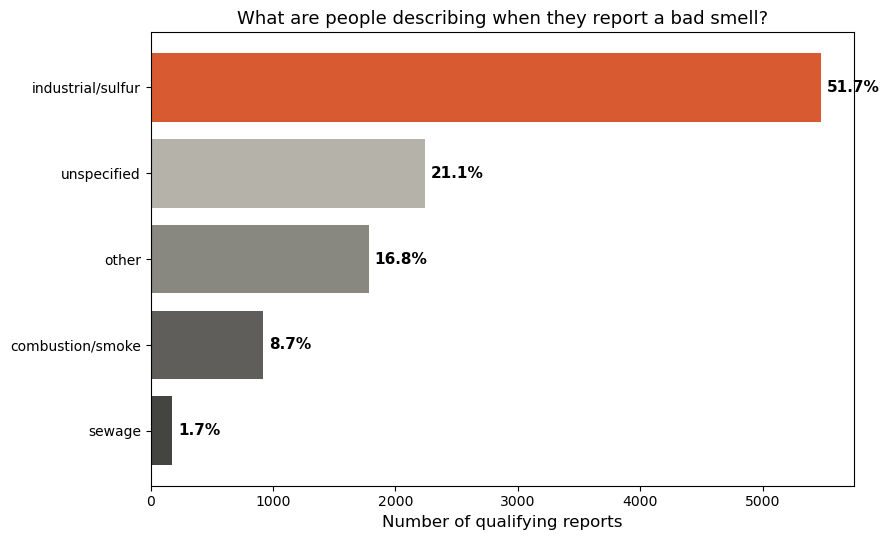

Roughly half of all qualifying reports are unambiguously industrial/sulfur-type smells —
directly consistent with the facility being modeled. The other half are either vague
("unspecified"/"other") or describe something else entirely (traffic exhaust, woodsmoke,
sewage). That second half is worth filtering out in any future agreement analysis — it
may be partly responsible for the "smell only" disagreement days found earlier, since
those reports might not be about the plant at all.


In [6]:
fig, ax = plt.subplots(figsize=(9, 5.5))

cat_colors = {'industrial/sulfur': '#D85A30', 'unspecified': '#B4B2A9',
             'other': '#888780', 'combustion/smoke': '#5F5E5A', 'sewage': '#444441'}
colors_bar = [cat_colors[c] for c in cat_counts.index]

bars = ax.barh(cat_counts.index, cat_counts.values, color=colors_bar)
for bar, pct in zip(bars, cat_pct.reindex(cat_counts.index)):
    ax.text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2,
            f'{pct}%', va='center', fontsize=11, fontweight='bold')

ax.set_xlabel('Number of qualifying reports', fontsize=12)
ax.set_title('What are people describing when they report a bad smell?', fontsize=13)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('part1_description_categories.png', dpi=140, bbox_inches='tight')
plt.show()

print('Roughly half of all qualifying reports are unambiguously industrial/sulfur-type smells —')
print('directly consistent with the facility being modeled. The other half are either vague')
print('("unspecified"/"other") or describe something else entirely (traffic exhaust, woodsmoke,')
print('sewage). That second half is worth filtering out in any future agreement analysis — it')
print('may be partly responsible for the "smell only" disagreement days found earlier, since')
print('those reports might not be about the plant at all.')

---
## Part 2 — Building out the neighborhood map: does the smell signature change with distance?

If the industrial-type smells really are coming from the plant, neighborhoods closer to it should report a *higher percentage* of industrial/sulfur descriptions, while distant neighborhoods should report more generic urban smells (traffic, sewage, woodsmoke) that have nothing to do with the facility.

In [7]:
def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371
    phi1, phi2 = math.radians(lat1), math.radians(lat2)
    dphi = math.radians(lat2 - lat1)
    dlambda = math.radians(lon2 - lon1)
    a = math.sin(dphi/2)**2 + math.cos(phi1)*math.cos(phi2)*math.sin(dlambda/2)**2
    return 2 * R * math.asin(math.sqrt(a))


# Stitch the neighborhood + county map (same approach as the earlier neighborhood notebook)
neighborhoods = gpd.read_file(NEIGHBORHOODS_GEOJSON)
county = gpd.read_file(COUNTY_GEOJSON)
county_minus_pgh = county[county['NAME'].str.upper() != 'PITTSBURGH'].copy()
neigh_clean = neighborhoods[['hood', 'geometry']].rename(columns={'hood': 'area_name'}).copy()
neigh_clean['area_type'] = 'neighborhood'
county_clean = county_minus_pgh[['NAME', 'geometry']].rename(columns={'NAME': 'area_name'}).copy()
county_clean['area_type'] = 'municipality'
stitched = pd.concat([neigh_clean, county_clean], ignore_index=True)
stitched = gpd.GeoDataFrame(stitched, geometry='geometry', crs=neighborhoods.crs)

# Assign every qualifying report to an area
geometry = [Point(lon, lat) for lon, lat in zip(qual['skewed longitude'], qual['skewed latitude'])]
qual_gdf = gpd.GeoDataFrame(qual, geometry=geometry, crs='EPSG:4326')
qual_with_area = gpd.sjoin(qual_gdf, stitched[['area_name', 'area_type', 'geometry']],
                           how='left', predicate='within')

print(f'Reports assigned to an area: {qual_with_area["area_name"].notna().sum():,} / {len(qual_with_area):,}')

Reports assigned to an area: 10,565 / 10,597


In [8]:
area_stats = qual_with_area.dropna(subset=['area_name']).groupby('area_name').agg(
    total_reports=('smell value', 'count'),
    mean_severity=('smell value', 'mean'),
    n_industrial=('category', lambda x: (x == 'industrial/sulfur').sum()),
    mean_lat=('skewed latitude', 'mean'),
    mean_lon=('skewed longitude', 'mean'),
).reset_index()

area_stats['pct_industrial'] = area_stats['n_industrial'] / area_stats['total_reports'] * 100
area_stats['distance_to_plant_km'] = area_stats.apply(
    lambda r: haversine_km(PLANT_LAT, PLANT_LON, r['mean_lat'], r['mean_lon']), axis=1)
area_stats['distance_to_clairton_km'] = area_stats.apply(
    lambda r: haversine_km(CLAIRTON_LAT, CLAIRTON_LON, r['mean_lat'], r['mean_lon']), axis=1)

analysis_areas_stats = area_stats[area_stats['total_reports'] >= MIN_REPORTS_FOR_ANALYSIS].copy()
analysis_areas_stats = analysis_areas_stats.sort_values('total_reports', ascending=False)

print(f'Areas with ≥{MIN_REPORTS_FOR_ANALYSIS} reports: {len(analysis_areas_stats)}')
print(analysis_areas_stats[['area_name', 'total_reports', 'mean_severity', 'pct_industrial',
                           'distance_to_plant_km']].head(15).to_string(index=False))

Areas with ≥50 reports: 54
          area_name  total_reports  mean_severity  pct_industrial  distance_to_plant_km
Squirrel Hill South            750       4.192000       52.266667              6.876004
        WILKINSBURG            490       4.181633       54.081633              5.785846
    JEFFERSON HILLS            481       4.451143       55.093555             12.656245
           EDGEWOOD            478       4.085774       64.853556              4.956182
          SWISSVALE            425       4.162353       53.176471              4.346257
       WEST MIFFLIN            364       4.260989       57.417582              5.404533
       Point Breeze            354       4.330508       58.757062              7.554301
      MOUNT LEBANON            319       3.968652       52.978056             16.412661
   Brighton Heights            310       4.270968       16.129032             19.245737
Squirrel Hill North            303       4.247525       58.415842              8.399873
     

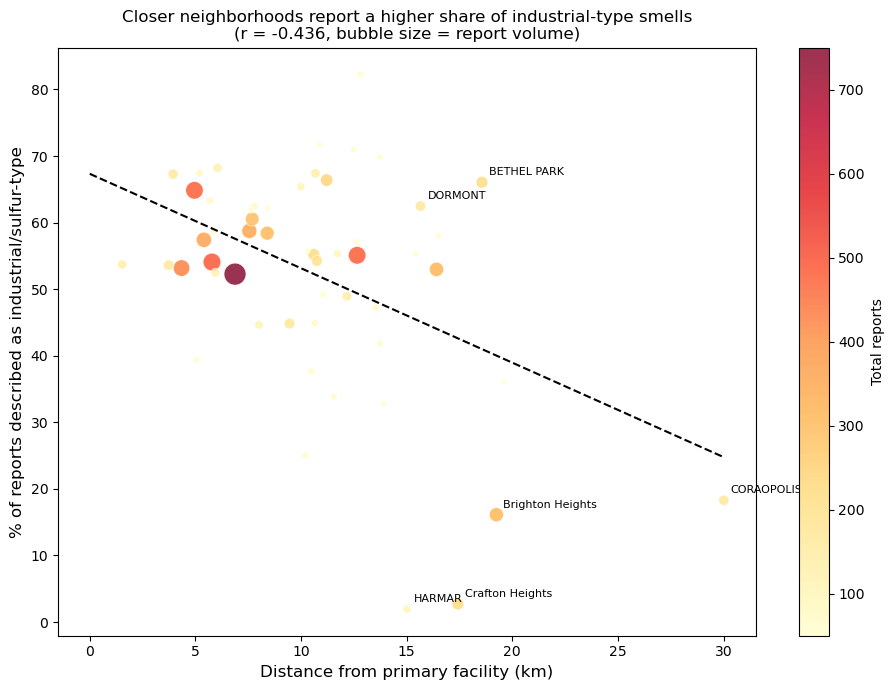

Correlation: distance from plant vs. % industrial-type reports: r = -0.436
A negative correlation here is exactly what we'd expect if the plant is the dominant
industrial-smell source for nearby areas, while far-away areas are reporting other things.


In [9]:
fig, ax = plt.subplots(figsize=(9.5, 7))

sc = ax.scatter(
    analysis_areas_stats['distance_to_plant_km'], analysis_areas_stats['pct_industrial'],
    s=analysis_areas_stats['total_reports'] / 3, c=analysis_areas_stats['total_reports'],
    cmap='YlOrRd', alpha=0.8, edgecolors='white', linewidth=0.5
)
plt.colorbar(sc, label='Total reports')

z = np.polyfit(analysis_areas_stats['distance_to_plant_km'], analysis_areas_stats['pct_industrial'], 1)
x_line = np.linspace(0, analysis_areas_stats['distance_to_plant_km'].max(), 100)
ax.plot(x_line, np.poly1d(z)(x_line), color='black', linestyle='--', linewidth=1.5)

r = analysis_areas_stats['distance_to_plant_km'].corr(analysis_areas_stats['pct_industrial'])

# Label the most interesting outliers
for _, row in analysis_areas_stats.iterrows():
    if row['pct_industrial'] < 20 or (row['pct_industrial'] > 60 and row['distance_to_plant_km'] > 15):
        ax.annotate(row['area_name'], (row['distance_to_plant_km'], row['pct_industrial']),
                    fontsize=8, xytext=(5, 5), textcoords='offset points')

ax.set_xlabel('Distance from primary facility (km)', fontsize=12)
ax.set_ylabel('% of reports described as industrial/sulfur-type', fontsize=12)
ax.set_title(f'Closer neighborhoods report a higher share of industrial-type smells\n'
             f'(r = {r:.3f}, bubble size = report volume)', fontsize=12)
plt.tight_layout()
plt.savefig('part2_distance_decay.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Correlation: distance from plant vs. % industrial-type reports: r = {r:.3f}')
print('A negative correlation here is exactly what we\'d expect if the plant is the dominant')
print('industrial-smell source for nearby areas, while far-away areas are reporting other things.')

### Mapping the percentage of industrial-type reports across the region

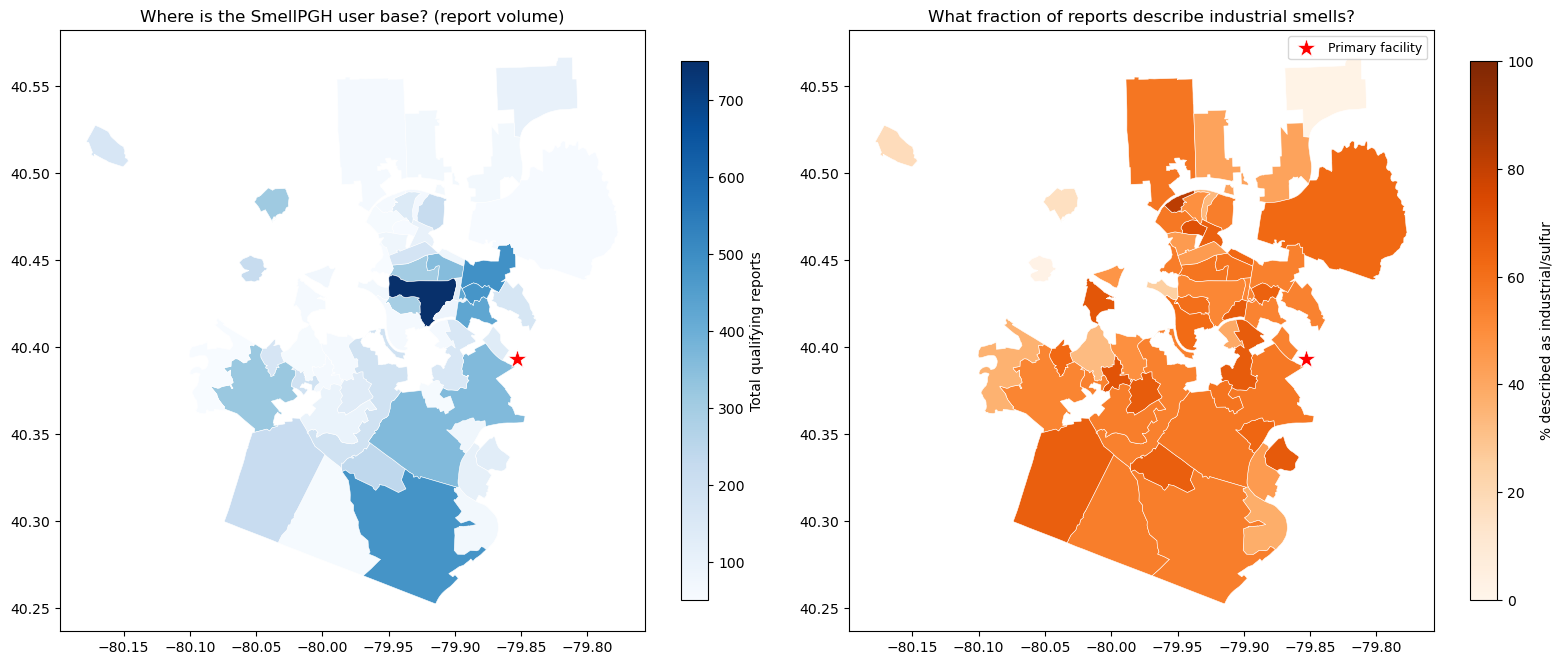

In [10]:
map_data = stitched.merge(analysis_areas_stats, on='area_name', how='inner')

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

map_data.plot(
    column='total_reports', cmap='Blues', ax=axes[0],
    edgecolor='white', linewidth=0.4, legend=True,
    legend_kwds={'label': 'Total qualifying reports', 'shrink': 0.7}
)
axes[0].scatter([PLANT_LON], [PLANT_LAT], marker='*', c='red', s=200, zorder=5,
                edgecolors='white', linewidth=0.5)
axes[0].set_title('Where is the SmellPGH user base? (report volume)', fontsize=12)

map_data.plot(
    column='pct_industrial', cmap='Oranges', ax=axes[1],
    edgecolor='white', linewidth=0.4, legend=True, vmin=0, vmax=100,
    legend_kwds={'label': '% described as industrial/sulfur', 'shrink': 0.7}
)
axes[1].scatter([PLANT_LON], [PLANT_LAT], marker='*', c='red', s=200, zorder=5,
                edgecolors='white', linewidth=0.5, label='Primary facility')
axes[1].set_title('What fraction of reports describe industrial smells?', fontsize=12)
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('part2_neighborhood_maps.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Part 3 — Understanding the user base: engagement patterns

Beyond *where* people report, it's worth understanding *how* they report — does an area have a few people reporting very frequently, or many people reporting occasionally? Is reporting concentrated on weekdays?

In [11]:
qual_with_area = qual_with_area.dropna(subset=['area_name']).copy()
qual_with_area['date'] = pd.to_datetime(qual_with_area['date & time'].str[:10], format='%m/%d/%Y')
qual_with_area['dow'] = qual_with_area['date'].dt.day_name()
qual_with_area['is_weekend'] = qual_with_area['dow'].isin(['Saturday', 'Sunday'])

# Weekday vs weekend reporting rate, normalized per day (5 weekdays, 2 weekend days per week)
wk = qual_with_area.groupby(['area_name', 'is_weekend']).size().unstack(fill_value=0)
wk.columns = ['weekday_reports', 'weekend_reports']
n_weeks = (qual_with_area['date'].max() - qual_with_area['date'].min()).days / 7
wk['weekday_avg_per_day'] = wk['weekday_reports'] / 5 / n_weeks
wk['weekend_avg_per_day'] = wk['weekend_reports'] / 2 / n_weeks
wk['weekday_weekend_ratio'] = wk['weekday_avg_per_day'] / wk['weekend_avg_per_day'].replace(0, np.nan)

# Reporting consistency — bursty (few intense days) vs steady (many moderate days)
consistency = qual_with_area.groupby('area_name').agg(
    total_reports=('smell value', 'count'),
    unique_days=('date', 'nunique')
).reset_index()
consistency['reports_per_active_day'] = consistency['total_reports'] / consistency['unique_days']

engagement = consistency.merge(wk.reset_index(), on='area_name')
engagement_top = engagement[engagement['total_reports'] >= MIN_REPORTS_FOR_ANALYSIS].sort_values(
    'total_reports', ascending=False)

print(engagement_top[['area_name', 'total_reports', 'unique_days', 'reports_per_active_day',
                      'weekday_weekend_ratio']].head(15).to_string(index=False))

          area_name  total_reports  unique_days  reports_per_active_day  weekday_weekend_ratio
Squirrel Hill South            750          177                4.237288               1.758273
        WILKINSBURG            490          170                2.882353               1.398165
    JEFFERSON HILLS            481          174                2.764368               1.216807
           EDGEWOOD            478          172                2.779070               1.531313
          SWISSVALE            425          164                2.591463               1.623810
       WEST MIFFLIN            364          159                2.289308               1.594521
       Point Breeze            354          130                2.723077               1.594366
      MOUNT LEBANON            319          117                2.726496               0.902041
   Brighton Heights            310          202                1.534653               1.076190
Squirrel Hill North            303          125   

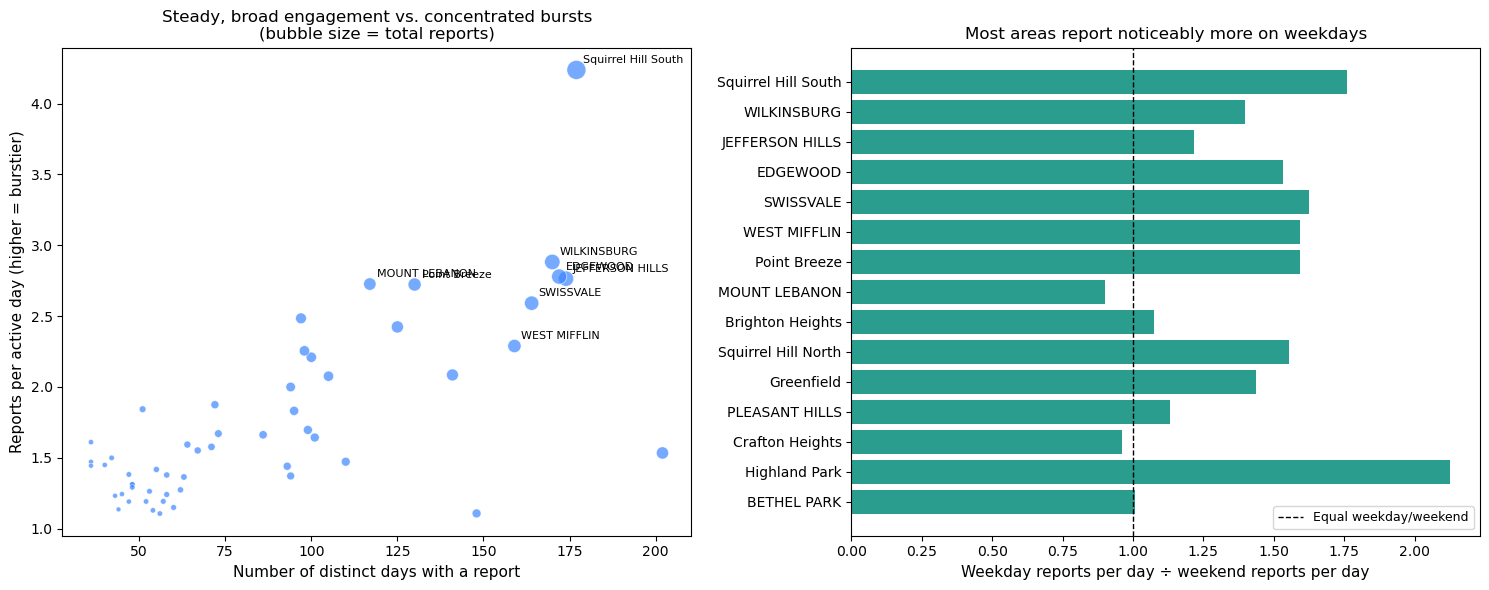

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Bursty vs steady reporting
axes[0].scatter(engagement_top['unique_days'], engagement_top['reports_per_active_day'],
               s=engagement_top['total_reports']/4, alpha=0.7, color='#3a86ff',
               edgecolors='white', linewidth=0.5)
for _, row in engagement_top.head(8).iterrows():
    axes[0].annotate(row['area_name'], (row['unique_days'], row['reports_per_active_day']),
                     fontsize=8, xytext=(5, 5), textcoords='offset points')
axes[0].set_xlabel('Number of distinct days with a report', fontsize=11)
axes[0].set_ylabel('Reports per active day (higher = burstier)', fontsize=11)
axes[0].set_title('Steady, broad engagement vs. concentrated bursts\n(bubble size = total reports)', fontsize=12)

# Weekday/weekend ratio
top10 = engagement_top.head(15)
axes[1].barh(top10['area_name'], top10['weekday_weekend_ratio'], color='#2A9D8F')
axes[1].axvline(1.0, color='black', linestyle='--', linewidth=1, label='Equal weekday/weekend')
axes[1].set_xlabel('Weekday reports per day ÷ weekend reports per day', fontsize=11)
axes[1].set_title('Most areas report noticeably more on weekdays', fontsize=12)
axes[1].invert_yaxis()
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('part3_engagement_patterns.png', dpi=140, bbox_inches='tight')
plt.show()

### What symptoms are people reporting?

In [13]:
qual['symptom_clean'] = qual['symptoms'].apply(clean_text)

print(f'Reports with a symptom listed: {qual["symptom_clean"].notna().sum():,} '
      f'({100*qual["symptom_clean"].notna().mean():.1f}% of qualifying reports)')
print()
print('Top symptoms reported:')
print(qual['symptom_clean'].value_counts().head(12).to_string())

Reports with a symptom listed: 4,053 (38.3% of qualifying reports)

Top symptoms reported:
symptom_clean
headache                 449
sore throat              136
eye irritation            56
nausea                    55
cough                     36
headache, sore throat     33
coughing                  29
headache, nausea          28
difficulty breathing      20
headache, cough           20
asthma                    19
sore throat, headache     19


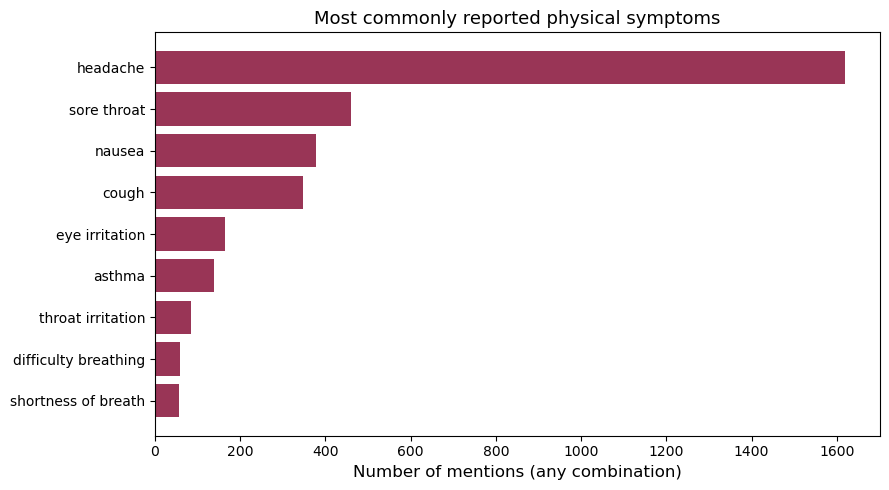

Headache dominates by a wide margin, followed by sore throat and nausea —
consistent with acute, low-level irritant exposure rather than anything more severe.


In [14]:
symptom_keywords = ['headache', 'sore throat', 'nausea', 'cough', 'eye irritation',
                    'asthma', 'shortness of breath', 'throat irritation', 'difficulty breathing']
symptom_counts = {kw: qual['symptom_clean'].str.contains(kw, na=False).sum() for kw in symptom_keywords}
symptom_series = pd.Series(symptom_counts).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(symptom_series.index, symptom_series.values, color='#993556')
ax.set_xlabel('Number of mentions (any combination)', fontsize=12)
ax.set_title('Most commonly reported physical symptoms', fontsize=13)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('part3_symptoms.png', dpi=140, bbox_inches='tight')
plt.show()

print('Headache dominates by a wide margin, followed by sore throat and nausea —')
print('consistent with acute, low-level irritant exposure rather than anything more severe.')

---
## Part 4 — Wind and inversion patterns

Now we turn to the wind data on its own terms — not just comparing individual days, but looking at the broader daily and seasonal rhythm, and testing whether overnight calm predicts next-morning reports.

In [15]:
with open(WIND_DATA_JSON) as f:
    raw_wind = json.load(f)

channel_names = raw_wind['channel_names']
cols = ['epoch'] + channel_names
wind_raw = pd.DataFrame(raw_wind['data'], columns=cols)
wind_raw['datetime'] = pd.to_datetime(wind_raw['epoch'], unit='s')

MS_TO_MPH = 2.23694
channel_pattern = re.compile(r'feed_(\w+)\.(\w+)')
long_rows = []
for col in channel_names:
    match = channel_pattern.search(col)
    feed_id = f'feed_{match.group(1)}'
    measure = match.group(2)
    is_speed = 'WS' in measure
    is_direction = 'WD' in measure
    is_metric = 'M_SEC' in measure
    sub = wind_raw[['datetime', col]].dropna()
    for _, row in sub.iterrows():
        value = row[col]
        if is_speed and is_metric:
            value = value * MS_TO_MPH
        long_rows.append({'datetime': row['datetime'], 'feed_id': feed_id,
                          'speed_mph': value if is_speed else np.nan,
                          'direction_deg': value if is_direction else np.nan})

wind_long = pd.DataFrame(long_rows)
speed_wide = wind_long.dropna(subset=['speed_mph'])[['datetime', 'feed_id', 'speed_mph']]
dir_wide   = wind_long.dropna(subset=['direction_deg'])[['datetime', 'feed_id', 'direction_deg']]
wind_clean = speed_wide.merge(dir_wide, on=['datetime', 'feed_id'], how='outer')

nb = wind_clean[wind_clean['feed_id'] == PRIMARY_WIND_FEED].copy()
nb['hour'] = nb['datetime'].dt.hour
nb['month'] = nb['datetime'].dt.month
nb['date_str'] = nb['datetime'].dt.strftime('%Y%m%d')

print(f'North Braddock hourly records: {len(nb):,}')
print(f'Date range: {nb["datetime"].min()} to {nb["datetime"].max()}')

North Braddock hourly records: 21,321
Date range: 2023-12-31 16:30:00 to 2026-06-08 17:30:00


### The diurnal cycle — does wind reliably calm down at certain hours?

This is the classic signature of a temperature inversion: at night, the ground cools faster than the air above it, creating a stable layer that traps pollution close to the surface with very little wind to disperse it. Once the sun comes up and heats the ground, that stable layer breaks down and wind picks up.

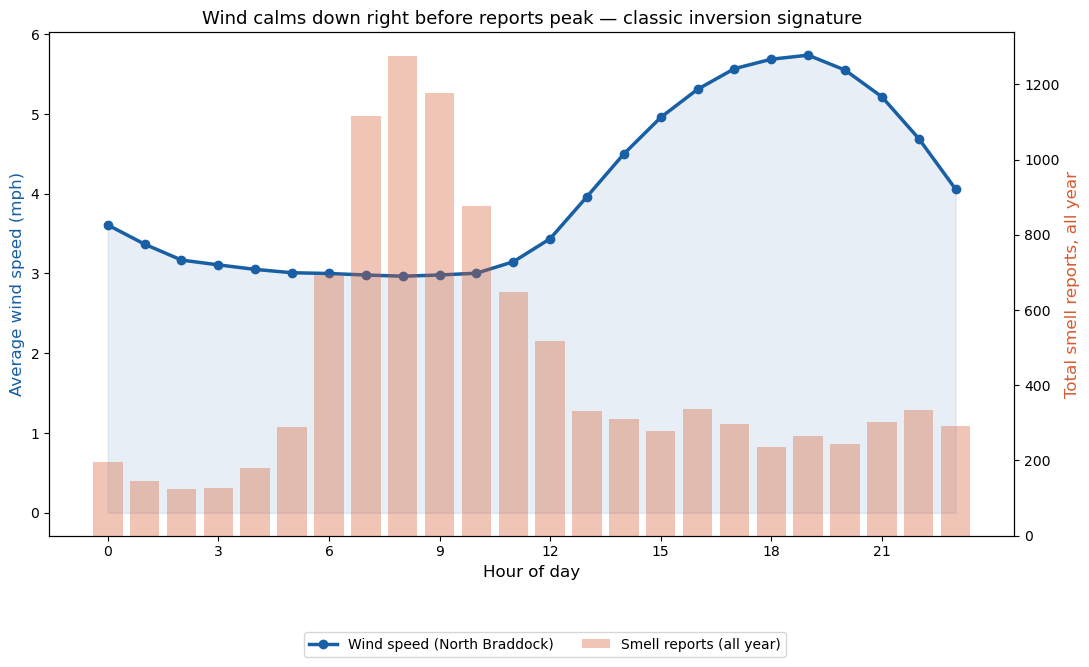

Calmest wind hour: 8:00 (2.97 mph)
Busiest reporting hour: 8:00 (1,275 reports)
Windiest hour: 19:00 (5.74 mph)


In [16]:
hourly_avg = nb.groupby('hour')['speed_mph'].mean()

# Overlay with the actual hourly distribution of smell reports for direct comparison
qual['report_hour'] = pd.to_datetime(
    qual['date & time'].str[:19], format='%m/%d/%Y %H:%M:%S'
).dt.hour
hourly_reports = qual.groupby('report_hour').size()

fig, ax1 = plt.subplots(figsize=(11, 6))
ax2 = ax1.twinx()

ax1.plot(hourly_avg.index, hourly_avg.values, 'o-', color='#185FA5', linewidth=2.5,
         label='Wind speed (North Braddock)')
ax1.fill_between(hourly_avg.index, hourly_avg.values, alpha=0.1, color='#185FA5')
ax2.bar(hourly_reports.index, hourly_reports.values, alpha=0.35, color='#D85A30',
        label='Smell reports (all year)')

ax1.set_xlabel('Hour of day', fontsize=12)
ax1.set_ylabel('Average wind speed (mph)', fontsize=12, color='#185FA5')
ax2.set_ylabel('Total smell reports, all year', fontsize=12, color='#D85A30')
ax1.set_title('Wind calms down right before reports peak — classic inversion signature', fontsize=13)
ax1.set_xticks(range(0, 24, 3))
fig.legend(loc='upper center', bbox_to_anchor=(0.5, -0.05), ncol=2, fontsize=10)

plt.tight_layout()
plt.savefig('part4_diurnal_cycle.png', dpi=150, bbox_inches='tight')
plt.show()

calmest_hour = hourly_avg.idxmin()
busiest_report_hour = hourly_reports.idxmax()
print(f'Calmest wind hour: {calmest_hour}:00 ({hourly_avg.min():.2f} mph)')
print(f'Busiest reporting hour: {busiest_report_hour}:00 ({hourly_reports.max():,} reports)')
print(f'Windiest hour: {hourly_avg.idxmax()}:00 ({hourly_avg.max():.2f} mph)')

### The seasonal cycle — which months are calmest?

Worth checking against intuition: Pittsburgh has a well-known history with inversion events — the 1948 Donora smog disaster happened just down the river, in late October, during a multi-day stagnant high-pressure system. Let's see whether this region's wind data shows fall as a particularly calm season, or whether the pattern is different.

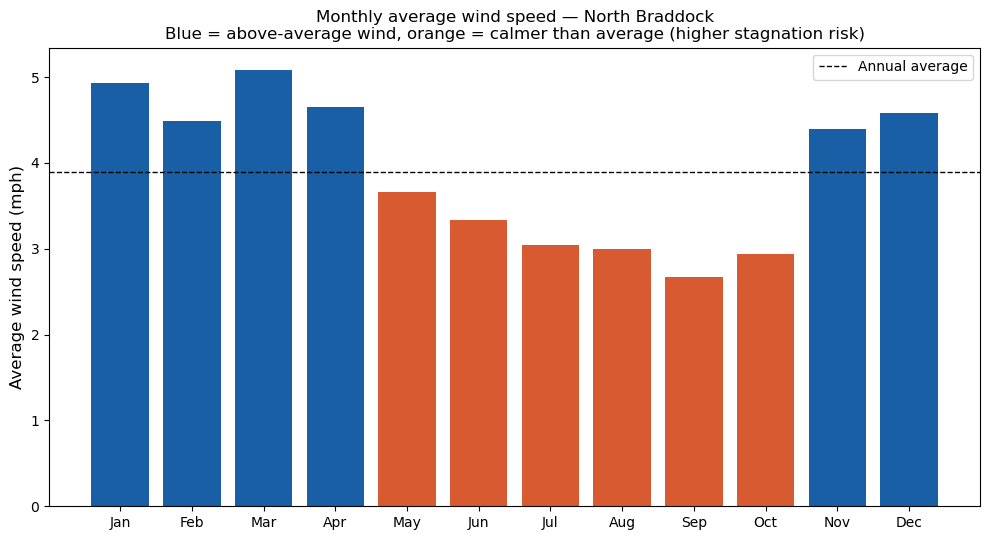

Three calmest months on average:
  Sep: 2.67 mph
  Oct: 2.94 mph
  Aug: 2.99 mph

Late summer and early fall (Aug-Oct) come out calmest in this data — broadly consistent
with the kind of stagnant high-pressure pattern behind historical regional inversion events,
though this single year of data is not enough to draw a firm seasonal conclusion on its own.


In [17]:
monthly_avg = nb.groupby('month')['speed_mph'].mean()
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

fig, ax = plt.subplots(figsize=(10, 5.5))
colors_month = ['#185FA5' if v > monthly_avg.median() else '#D85A30' for v in monthly_avg.values]
ax.bar([month_names[m-1] for m in monthly_avg.index], monthly_avg.values, color=colors_month)
ax.axhline(monthly_avg.mean(), color='black', linestyle='--', linewidth=1, label='Annual average')
ax.set_ylabel('Average wind speed (mph)', fontsize=12)
ax.set_title('Monthly average wind speed — North Braddock\n'
             'Blue = above-average wind, orange = calmer than average (higher stagnation risk)',
             fontsize=12)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('part4_seasonal_wind.png', dpi=140, bbox_inches='tight')
plt.show()

calmest_months = monthly_avg.sort_values().head(3)
print('Three calmest months on average:')
for m, v in calmest_months.items():
    print(f'  {month_names[m-1]}: {v:.2f} mph')
print()
print('Late summer and early fall (Aug-Oct) come out calmest in this data — broadly consistent')
print('with the kind of stagnant high-pressure pattern behind historical regional inversion events,')
print('though this single year of data is not enough to draw a firm seasonal conclusion on its own.')

### Does overnight calm predict next-morning reports?

If pollution accumulates overnight under a stable inversion layer, the smell the next morning might be driven as much by how calm the *whole night* was as by the wind at the exact moment someone steps outside. We test this directly: compare the overnight average wind speed (midnight–6am) against the number of smell reports that come in the following morning (6am–noon).

Days with complete overnight + morning data: 341
Overnight (12am-6am) wind vs. next-morning reports:  r = -0.375
Same-morning (6am-12pm) wind vs. morning reports:    r = -0.388


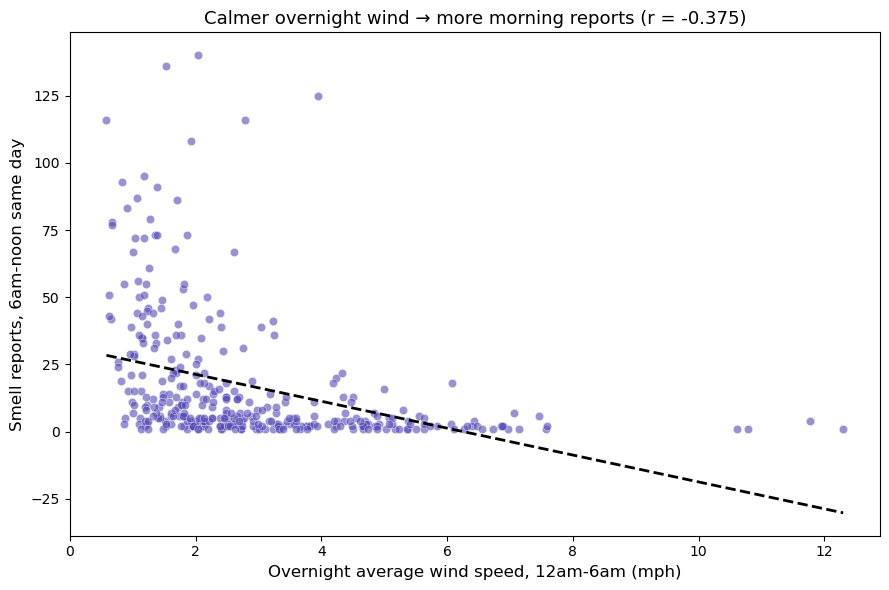


The overnight correlation is nearly as strong as the same-morning correlation — meaning
accumulated overnight stagnation matters about as much as the wind at the moment someone
steps outside. This supports the idea that pollution is building up over the calm overnight
hours and is still concentrated when people wake up, rather than appearing fresh each morning.


In [18]:
qual['report_datetime'] = pd.to_datetime(qual['date & time'].str[:19], format='%m/%d/%Y %H:%M:%S')
qual['date_str'] = qual['report_datetime'].dt.strftime('%Y%m%d')

overnight_wind = nb[nb['hour'] <= 5].groupby('date_str')['speed_mph'].mean().rename('overnight_speed_mph')
morning_wind   = nb[(nb['hour'] >= 6) & (nb['hour'] <= 11)].groupby('date_str')['speed_mph'].mean().rename('morning_speed_mph')
morning_reports = qual[(qual['report_hour'] >= 6) & (qual['report_hour'] <= 11)].groupby('date_str').size().rename('morning_reports')

lag_df = pd.concat([overnight_wind, morning_wind, morning_reports], axis=1).dropna()

r_overnight = lag_df['overnight_speed_mph'].corr(lag_df['morning_reports'])
r_morning   = lag_df['morning_speed_mph'].corr(lag_df['morning_reports'])

print(f'Days with complete overnight + morning data: {len(lag_df)}')
print(f'Overnight (12am-6am) wind vs. next-morning reports:  r = {r_overnight:.3f}')
print(f'Same-morning (6am-12pm) wind vs. morning reports:    r = {r_morning:.3f}')

fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(lag_df['overnight_speed_mph'], lag_df['morning_reports'],
           alpha=0.6, color='#534AB7', edgecolors='white', linewidth=0.4)
z = np.polyfit(lag_df['overnight_speed_mph'], lag_df['morning_reports'], 1)
x_line = np.linspace(lag_df['overnight_speed_mph'].min(), lag_df['overnight_speed_mph'].max(), 100)
ax.plot(x_line, np.poly1d(z)(x_line), color='black', linestyle='--', linewidth=2)
ax.set_xlabel('Overnight average wind speed, 12am-6am (mph)', fontsize=12)
ax.set_ylabel('Smell reports, 6am-noon same day', fontsize=12)
ax.set_title(f'Calmer overnight wind → more morning reports (r = {r_overnight:.3f})', fontsize=13)
plt.tight_layout()
plt.savefig('part4_overnight_lag.png', dpi=150, bbox_inches='tight')
plt.show()

print()
print('The overnight correlation is nearly as strong as the same-morning correlation — meaning')
print('accumulated overnight stagnation matters about as much as the wind at the moment someone')
print('steps outside. This supports the idea that pollution is building up over the calm overnight')
print('hours and is still concentrated when people wake up, rather than appearing fresh each morning.')

### Does the seasonal wind pattern show up in report volume too?

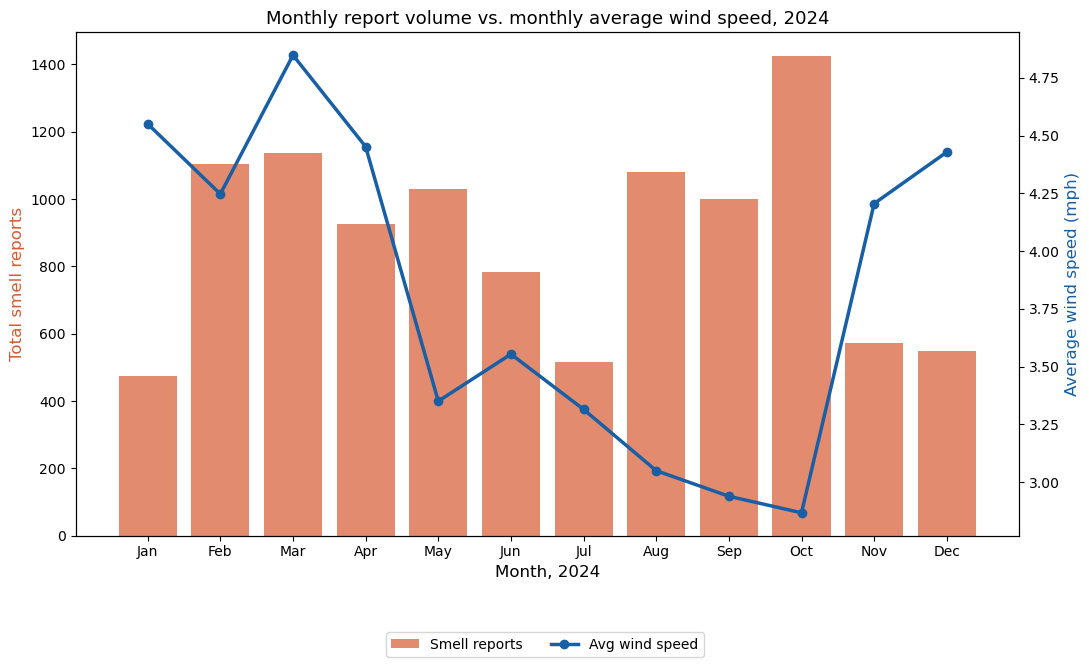

Correlation, monthly report volume vs. monthly average wind speed: r = -0.369

The relationship holds at the monthly level too, though it's noisier — February and March
both had high wind AND high reports, so wind clearly isn't the only thing driving monthly
report volume (heating season emissions, seasonal outdoor activity, etc. likely also play a role).


In [19]:
qual['report_month'] = qual['report_datetime'].dt.month
qual['report_year']  = qual['report_datetime'].dt.year

monthly_reports_2024 = qual[qual['report_year'] == 2024].groupby('report_month').size()
nb_2024 = nb[nb['datetime'].dt.year == 2024]
monthly_wind_2024 = nb_2024.groupby(nb_2024['datetime'].dt.month)['speed_mph'].mean()

fig, ax1 = plt.subplots(figsize=(11, 6))
ax2 = ax1.twinx()

x = monthly_reports_2024.index
ax1.bar(x, monthly_reports_2024.values, alpha=0.7, color='#D85A30', label='Smell reports')
ax2.plot(monthly_wind_2024.index, monthly_wind_2024.values, 'o-', color='#185FA5',
         linewidth=2.5, label='Avg wind speed')

ax1.set_xticks(range(1, 13))
ax1.set_xticklabels(month_names)
ax1.set_xlabel('Month, 2024', fontsize=12)
ax1.set_ylabel('Total smell reports', fontsize=12, color='#D85A30')
ax2.set_ylabel('Average wind speed (mph)', fontsize=12, color='#185FA5')
ax1.set_title('Monthly report volume vs. monthly average wind speed, 2024', fontsize=13)
fig.legend(loc='upper center', bbox_to_anchor=(0.5, -0.05), ncol=2, fontsize=10)

plt.tight_layout()
plt.savefig('part4_monthly_reports_vs_wind.png', dpi=150, bbox_inches='tight')
plt.show()

combo = pd.DataFrame({'reports': monthly_reports_2024, 'wind_speed': monthly_wind_2024}).dropna()
r_seasonal = combo['reports'].corr(combo['wind_speed'])
print(f'Correlation, monthly report volume vs. monthly average wind speed: r = {r_seasonal:.3f}')
print()
print('The relationship holds at the monthly level too, though it\'s noisier — February and March')
print('both had high wind AND high reports, so wind clearly isn\'t the only thing driving monthly')
print('report volume (heating season emissions, seasonal outdoor activity, etc. likely also play a role).')

---
## Save outputs

In [ ]:
raw.to_csv('smell_reports_categorized.csv', index=False)
area_stats.to_csv('neighborhood_full_stats.csv', index=False)
engagement.to_csv('neighborhood_engagement_stats.csv', index=False)
lag_df.to_csv('overnight_lag_analysis.csv')

print('Saved:')
print('  smell_reports_categorized.csv     — every report with description category')
print('  neighborhood_full_stats.csv       — per-area volume, severity, % industrial, distance')
print('  neighborhood_engagement_stats.csv — per-area weekday/weekend ratio, reporting consistency')
print('  overnight_lag_analysis.csv        — daily overnight wind vs. next-morning reports')

---
## Summary of what this notebook found

**On what people are smelling:** Roughly half of qualifying reports are unambiguously industrial/sulfur-type smells, and several hundred reports explicitly name US Steel or Clairton Coke Works by name — strong direct evidence the SmellPGH signal really is substantially about the facilities being modeled. The other half describe traffic exhaust, woodsmoke, sewage, or are too vague to categorize — these are probably not about the plant at all, and may be inflating the "disagreement" rate found in earlier analysis.

**On the user base geographically:** Neighborhoods closer to the primary facility report a higher percentage of industrial-type smells, exactly as you'd expect if the plant is genuinely the dominant nearby source. A few outliers (areas far from the plant but still reporting high industrial percentages) are worth a closer look — they may be near other unaccounted sources.

**On user engagement:** Most areas report more on weekdays than weekends, consistent with the morning-routine reporting bias found earlier. Headache is by far the most common symptom reported everywhere, suggesting fairly consistent, low-level acute irritation rather than anything more severe.

**On wind and inversions:** The diurnal wind cycle shows a textbook inversion signature — wind calms down overnight and into early morning, then picks up through the afternoon. The calmest hours line up closely with the hour smell reports peak. Overnight wind speed predicts next-morning reports almost as well as the wind at the moment of reporting, suggesting pollution genuinely accumulates overnight rather than appearing fresh each morning. The seasonal pattern points to late summer/early fall as the calmest, highest-stagnation-risk period in this data.

**For next steps:** The description-category filter is probably the single most promising lead from this notebook — re-running the plume-vs-smell agreement analysis using only "industrial/sulfur"-categorized reports (rather than all qualifying reports) could meaningfully improve the agreement rate, since it would strip out reports that were never about the plant in the first place.